In [65]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from astropy import wcs
from astropy.table import Table
import astropy.units as u
import regions
import numpy as np
from matplotlib.lines import Line2D

In [35]:
image_filenames_pipe ={
    "f150w": "/orange/adamginsburg/jwst/sgrb2/NB/F150W/pipeline/jw05365-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/sgrb2/NB/F182M/pipeline/jw05365-o001_t001_nircam_clear-f182m-merged_i2d.fits", 
    "f187n": "/orange/adamginsburg/jwst/sgrb2/NB/F187N/pipeline/jw05365-o001_t001_nircam_clear-f187n-merged_i2d.fits", 
    "f210m": "/orange/adamginsburg/jwst/sgrb2/NB/F210M/pipeline/jw05365-o001_t001_nircam_clear-f210m-merged_i2d.fits", 
    "f212n": "/orange/adamginsburg/jwst/sgrb2/NB/F212N/pipeline/jw05365-o001_t001_nircam_clear-f212n-merged_i2d.fits", 
    "f300m": "/orange/adamginsburg/jwst/sgrb2/NB/F300M/pipeline/jw05365-o001_t001_nircam_clear-f300m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/sgrb2/NB/F360M/pipeline/jw05365-o001_t001_nircam_clear-f360m-merged_i2d.fits", 
    "f405n": "/orange/adamginsburg/jwst/sgrb2/NB/F405N/pipeline/jw05365-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/sgrb2/NB/F410M/pipeline/jw05365-o001_t001_nircam_clear-f410m-merged_i2d.fits", 
    "f466n": "/orange/adamginsburg/jwst/sgrb2/NB/F466N/pipeline/jw05365-o001_t001_nircam_clear-f466n-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/sgrb2/NB/F480M/pipeline/jw05365-o001_t001_nircam_clear-f480m-merged_i2d.fits", 
    "f410m-f405n": "/orange/adamginsburg/jwst/sgrb2/NB/filter_subtractions/f405n_minus_f410m.fits",
    "f405n-f410m": "/orange/adamginsburg/jwst/sgrb2/NB/filter_subtractions/f405n_minus_f410m.fits",
    "f770w": "/orange/adamginsburg/jwst/sgrb2/NB/pipeline_reruns/MIRI_for_images_try2/jw05365-o002_t002_miri_f770w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/sgrb2/NB/pipeline_reruns/MIRI_for_images_try2/jw05365-o002_t002_miri_f1280w_i2d.fits",
    'f2550W': "/orange/adamginsburg/jwst/sgrb2/NB/pipeline_reruns/MIRI_for_images_try2/jw05365-o002_t002_miri_f2550w_i2d.fits",
}

In [36]:
f480m_wcs = wcs.WCS(fits.getheader(image_filenames_pipe["f480m"], ext=1))

Set DATE-AVG to '2024-09-07T14:47:53.677' from MJD-AVG.
Set DATE-END to '2024-09-07T15:32:14.489' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -4.717158 from OBSGEO-[XYZ].
Set OBSGEO-H to 1298812689.621 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [11]:
cat480dao = Table.read("/orange/adamginsburg/jwst/sgrb2/NB/F480M/f480m_merged_daophot_basic.fits")

In [24]:
cat480dao['skycoord_centroid']

<SkyCoord (ICRS): (ra, dec) in deg
    [(266.80988388, -28.42027633), (266.80987535, -28.41364536),
     (266.80987781, -28.41264087), ..., (266.85947057, -28.38303796),
     (266.8594761 , -28.38284131), (266.85948233, -28.38233417)]>

In [ ]:
cat

In [31]:
test_regions = regions.Regions.read("/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_refinment_test_regions.crtf", format="crtf") 


In [33]:
test_region1 = test_regions[0]
test_region2 = test_regions[1]

In [87]:
coords = cat480dao['skycoord_centroid']

# Boolean mask: True where source is inside region
mask = test_region1.contains(coords, wcs=f480m_wcs)

# Subset catalog
cat_in_region1 = cat480dao[mask]

mask2 = test_region2.contains(coords, wcs=f480m_wcs)
cat_in_region2 = cat480dao[mask2]

In [89]:
regs_region1_path = "/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_by_eye_region1_f480m.crtf"
regs_region1 = regions.Regions.read(regs_region1_path, format="crtf")
regs_region2_path = "/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_by_eye_region2_f480m.crtf"
regs_region2 = regions.Regions.read(regs_region2_path, format="crtf")

In [90]:
matched_indices = []

for source in regs_region1:
    idx, sep2d, _ = source.center.match_to_catalog_sky(
        cat480dao['skycoord_centroid']
    )

    if sep2d < 0.1 * u.arcsec:
        matched_indices.append(idx)

matched_cat1 = cat480dao[matched_indices]

matched_indices = []
for source in regs_region2:
    idx, sep2d, _ = source.center.match_to_catalog_sky(
        cat480dao['skycoord_centroid']
    )

    if sep2d < 0.1 * u.arcsec:
        matched_indices.append(idx)

matched_cat2 = cat480dao[matched_indices]


In [91]:
len(regs_region1)

215

In [92]:
len(regs_region2)

208

In [ ]:
cat_in_region

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fit,y_fit,flux_fit,x_err,y_err,flux_err,npixfit,qfit,cfit,flags,roundness1,roundness2,sharpness,skycoord_centroid,dra,ddec
,,,,,,,,,,,,,,,,,,,,"deg,deg",arcsec,arcsec
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float32,float64,float64,SkyCoord,float64,float64
247894,247894,1,15.193202018737793,999.3851862552493,2178.1949040954514,1652.0709584387228,997.5734489559967,2180.8781242774085,227.33502989241856,0.24948570993249256,0.5716536373800821,108.60671663927653,25,0.3018132797077366,0.03031656226298583,0,0.9610912,0.5423916905725188,0.5593701500758572,"266.85313979965264,-28.42985417443",0.015694773411247087,0.03596187657731295
248127,248127,1,14.780328750610352,972.9761442630573,2179.3726242191924,1636.5643682518487,972.8718901928289,2179.5796396762817,262.7529681366885,0.1414931616961915,0.1475163200355732,25.138939499451933,25,0.34826094168099964,-0.015583241843243736,0,0.61468637,-0.1270628427995871,0.504712443197264,"266.8531143466347,-28.430285839807684",0.008901123485844393,0.009280031381540054
248247,248247,1,14.924076080322266,997.4528961561476,2180.277153291138,3300.688804701677,997.3398584738218,2181.200204802359,296.9471796306922,0.1232445036043173,0.15134318359512983,25.686938421180034,25,0.29510286388230283,-0.0006081036806021305,0,0.1266122,0.8062647315974159,0.4653984206988035,"266.85314620302046,-28.429858252318258",0.007753127659194503,0.0095207736527477
248248,248248,1,15.256754398345947,1005.4647981892023,2179.9659897119345,2231.8515884271055,1005.4152448375835,2180.0047608465525,393.062243812517,0.052553178012200115,0.05495374168485742,14.235902635882189,25,0.1476135833204575,-0.008799793629683528,0,-0.35930428,-0.1464354255238073,0.516266143566906,"266.8531223341797,-28.42971715324395",0.00330604194190359,0.0034570578173692516
248371,248371,1,16.439971923828125,945.5432434506218,2180.7058313443717,1548.8002562846077,945.5205050658273,2180.720656574724,102.32042539113631,0.1079386485082292,0.1127462442184451,7.610273979323008,25,0.24225787226253848,-0.006645846939601103,0,-0.45435932,-0.15085156852812712,0.49381787077985817,"266.8531374066256,-28.43076377943255",0.0067902591740075765,0.007092697840114501
248372,248372,1,15.475841522216797,1010.0267231820827,2181.257818883532,2478.548175838847,1010.0299386031029,2181.261413977565,1198.5823455256966,0.028823052657734858,0.029288538925106303,23.38648128123508,25,0.08064207267956436,-0.00635985317068829,0,0.03031727,0.06337778296089469,0.5335064093281024,"266.8531472398535,-28.42963649780432",0.0018132151961969976,0.0018424982420853528
248373,248373,1,17.189258575439453,1028.5774120152473,2179.3452501769716,1511.4118515982352,1030.8072214912293,2179.2747068885064,92.01479611199258,0.06959939123085955,0.05175565220095749,3.4818827381382427,25,0.11280241871901621,0.001705600532062597,0,0.6590991,-0.3446502392316456,0.6950018576491369,"266.8531074683807,-28.429273448327464",0.004378393757400584,0.003255870784202971
248490,248490,1,14.738531112670898,928.1767337299746,2182.511677445547,1309.935488687776,928.2236657237933,2182.5816966362636,67.01839363011065,0.11314453938283621,0.11649633716069209,5.192832228731559,25,0.24467175395133678,-0.0013569482493217546,0,0.12231696,0.3203395845545327,0.5371583696504066,"266.8531746323655,-28.431066011184523",0.007117753994062578,0.007328610586442173


In [ ]:
np.unique(cat_in_region['flags'])

0
4
8
12


(array([293.,   0.,   0.,  29.,   0.,   0.,   4.,   0.,   0.,   8.]),
 array([ 0. ,  1.2,  2.4,  3.6,  4.8,  6. ,  7.2,  8.4,  9.6, 10.8, 12. ]),
 <BarContainer object of 10 artists>)

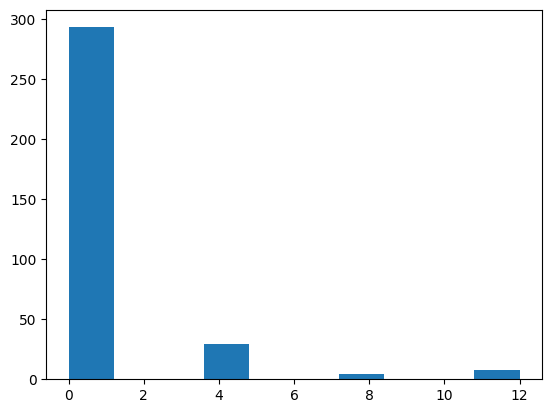

In [ ]:
plt.hist(cat_in_region['flags'])

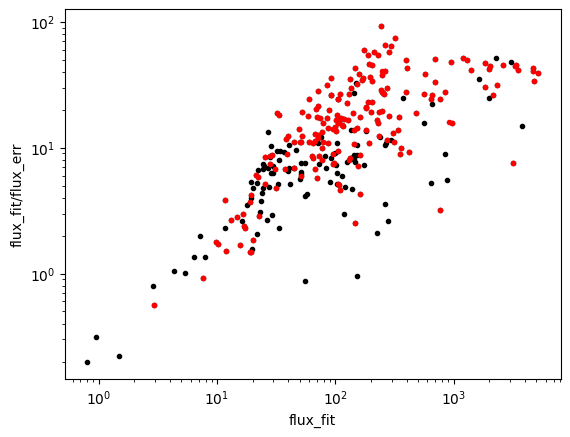

In [ ]:
plt.scatter(
    cat_in_region['flux_fit'],
    cat_in_region['flux_fit']/cat_in_region['flux_err'],
    marker='.', color = 'k')
plt.xlabel('flux_fit')
plt.ylabel('flux_fit/flux_err')

plt.scatter(
    matched_cat1['flux_fit'],
    matched_cat1['flux_fit']/matched_cat1['flux_err'],
    marker='.', color = 'red')
plt.xscale('log')
plt.yscale('log')

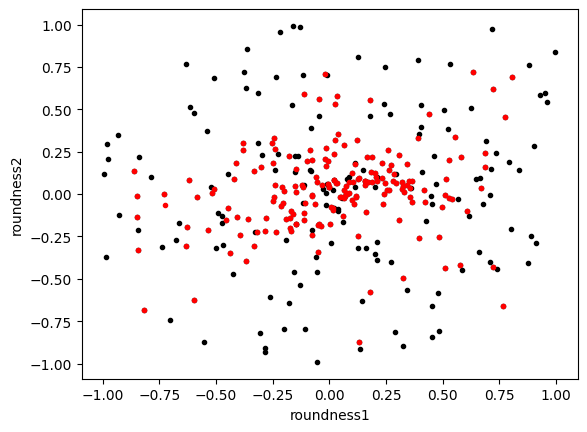

In [ ]:
plt.scatter(
    cat_in_region['roundness1'],
    cat_in_region['roundness2'],
    marker='.', color = 'k')
plt.xlabel('roundness1')
plt.ylabel('roundness2')

plt.scatter(
    matched_cat1['roundness1'],
    matched_cat1['roundness2'],
    marker='.', color = 'red')

(-2.0, 2.0)

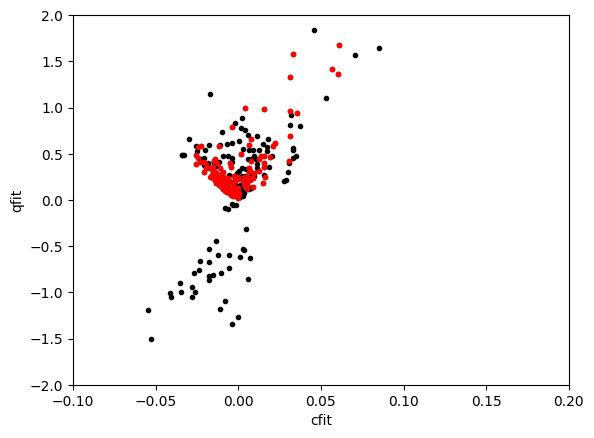

In [ ]:
plt.scatter(
    cat_in_region['cfit'],
    cat_in_region1['qfit'],
    marker='.', color = 'k')
plt.xlabel('cfit')
plt.ylabel('qfit')

plt.scatter(
    matched_cat1['cfit'],
    matched_cat1['qfit'],
    marker='.', color = 'red')
plt.xlim(-0.1,0.2)
plt.ylim(-2,2)

# suggested cut: remove qfit <0

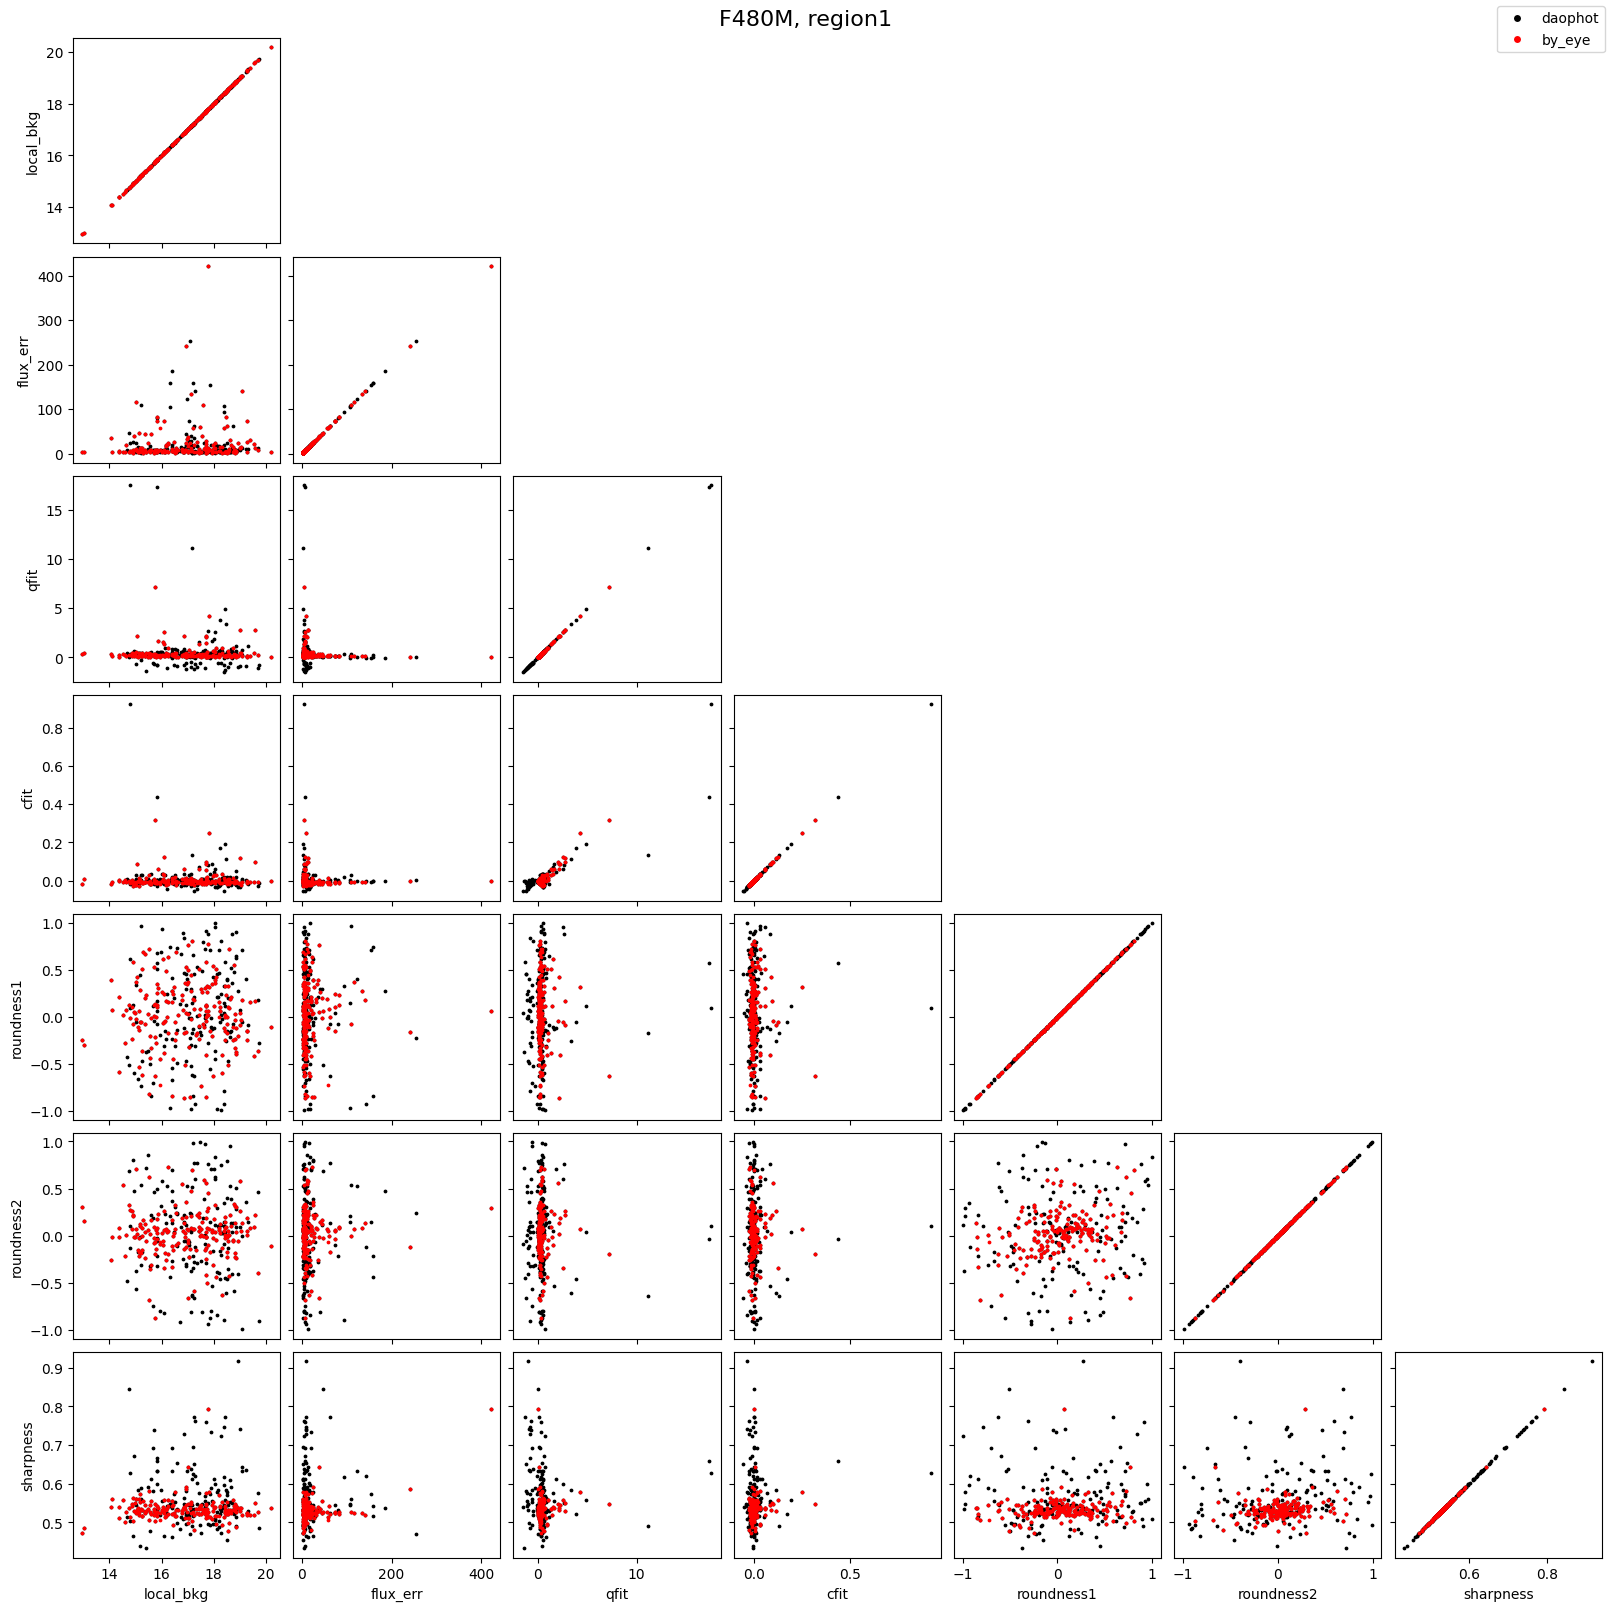

In [73]:
import itertools
import matplotlib.pyplot as plt

cols = [
    "local_bkg",
    "flux_err",
    "qfit",
    "cfit",
    "roundness1",
    "roundness2",
    "sharpness",
]

pairs = list(itertools.combinations(cols, 2))

n = len(cols)
fig, axes = plt.subplots(n, n, figsize=(16, 16), constrained_layout=True)

for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):

        ax = axes[i, j]

        if i < j:
            ax.set_visible(False)
            continue

        ax.scatter(
            cat_in_region1[col2],
            cat_in_region1[col1],
            s=3,
            c="k",
        )

        ax.scatter(
            matched_cat1[col2],
            matched_cat1[col1],
            s=3,
            c="red",
        )

        if i == n - 1:
            ax.set_xlabel(col2)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(col1)
        else:
            ax.set_yticklabels([])
fig.suptitle("F480M, region1", fontsize=16)





legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='k', markersize=6, label='daophot'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markersize=6, label='by_eye'),
]

fig.legend(handles=legend_elements)


In [ ]:
import numpy as np

cat_in_region = cat_in_region1
matched_cat = matched_cat1

# Make a dictionary of arrays for plotting
plot_cols = {
    "local_bkg": cat_in_region["local_bkg"],
    "flux_err": cat_in_region["flux_err"],
    "flux_fit": cat_in_region["flux_fit"],
    "qfit": cat_in_region["qfit"],
    "cfit": cat_in_region["cfit"],
    "roundness1": cat_in_region["roundness1"],
    "roundness2": cat_in_region["roundness2"],
    "sharpness": cat_in_region["sharpness"],
    "SNR": cat_in_region["flux_fit"] / cat_in_region["flux_err"],
}

# Do the same for matched_cat
plot_cols_matched = {
    k: (matched_cat[k] if k != "SNR" else matched_cat["flux_fit"] / matched_cat["flux_err"])
    for k in plot_cols
}

# Updated column order
cols = list(plot_cols.keys())
n = len(cols)

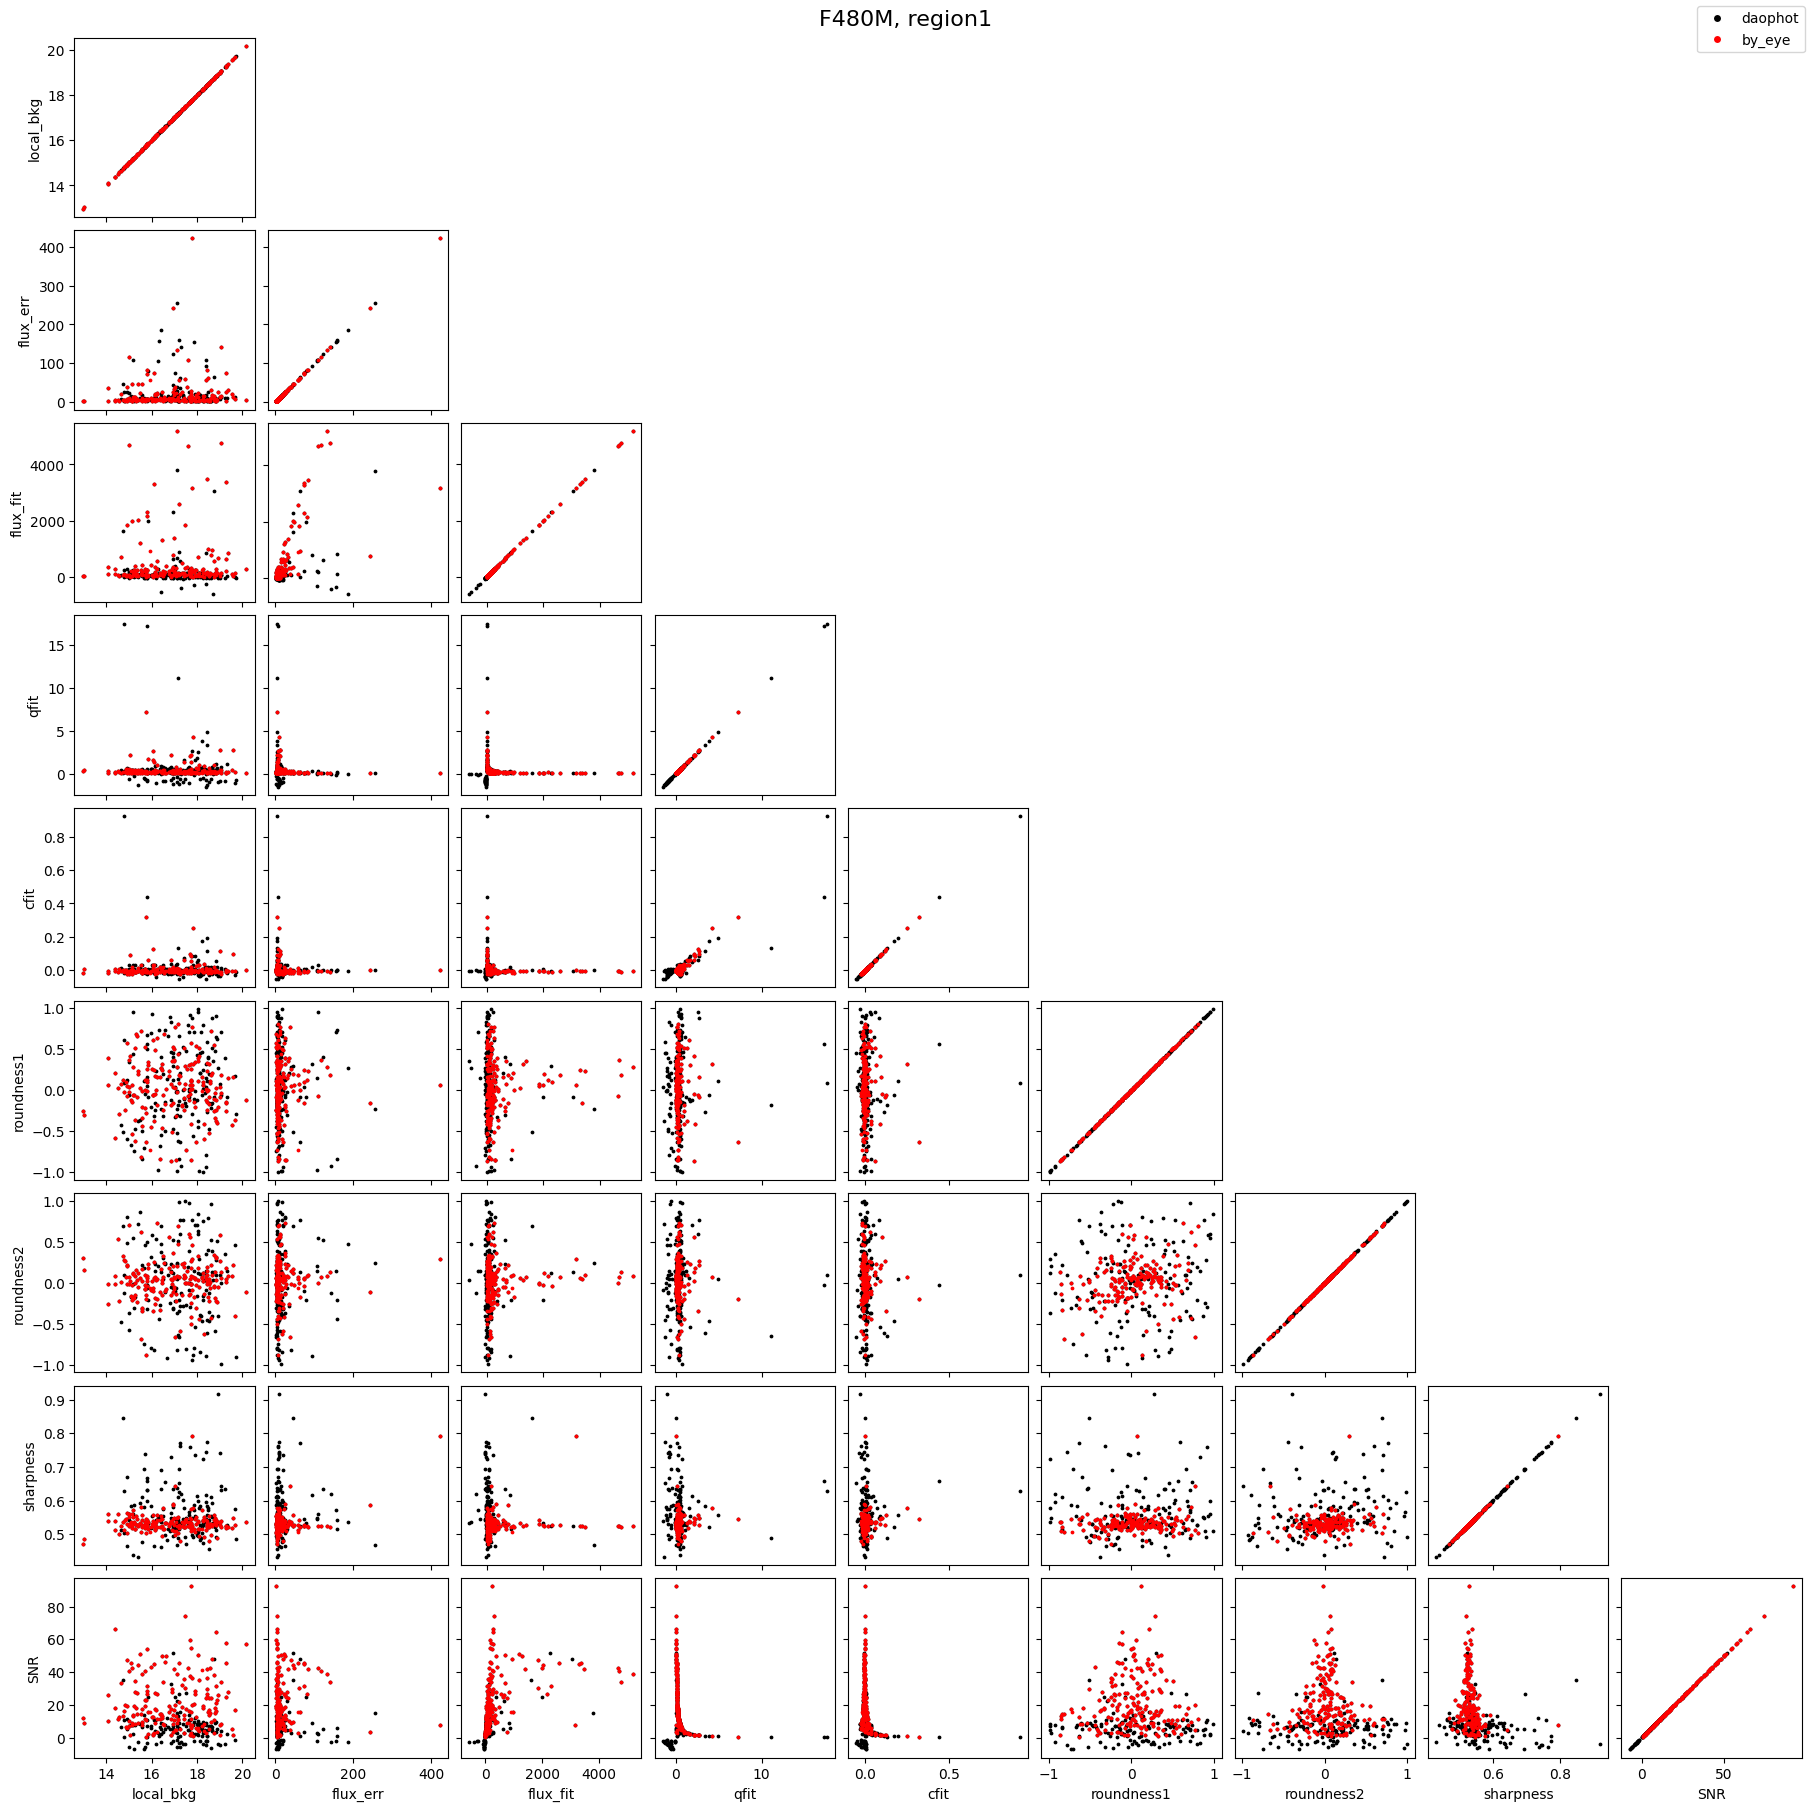

In [86]:
n = len(cols)  # updated, now 8
fig, axes = plt.subplots(n, n, figsize=(18, 18), constrained_layout=True)

for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):
        ax = axes[i, j]

        if j > i:
            ax.set_visible(False)
            continue

        ax.scatter(plot_cols[col2], plot_cols[col1], s=3, c="k")
        ax.scatter(plot_cols_matched[col2], plot_cols_matched[col1], s=3, c="red")

        if i == n - 1:
            ax.set_xlabel(col2)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(col1)
        else:
            ax.set_yticklabels([])


fig.suptitle("F480M, region1", fontsize=16)





legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='k', markersize=6, label='daophot'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markersize=6, label='by_eye'),
]

fig.legend(handles=legend_elements)


In [94]:
import numpy as np

cat_in_region = cat_in_region2
matched_cat = matched_cat2

# Make a dictionary of arrays for plotting
plot_cols = {
    "local_bkg": cat_in_region["local_bkg"],
    "flux_err": cat_in_region["flux_err"],
    "flux_fit": cat_in_region["flux_fit"],
    "qfit": cat_in_region["qfit"],
    "cfit": cat_in_region["cfit"],
    "roundness1": cat_in_region["roundness1"],
    "roundness2": cat_in_region["roundness2"],
    "sharpness": cat_in_region["sharpness"],
    "SNR": cat_in_region["flux_fit"] / cat_in_region["flux_err"],
}

# Do the same for matched_cat
plot_cols_matched = {
    k: (matched_cat[k] if k != "SNR" else matched_cat["flux_fit"] / matched_cat["flux_err"])
    for k in plot_cols
}

# Updated column order
cols = list(plot_cols.keys())
n = len(cols)

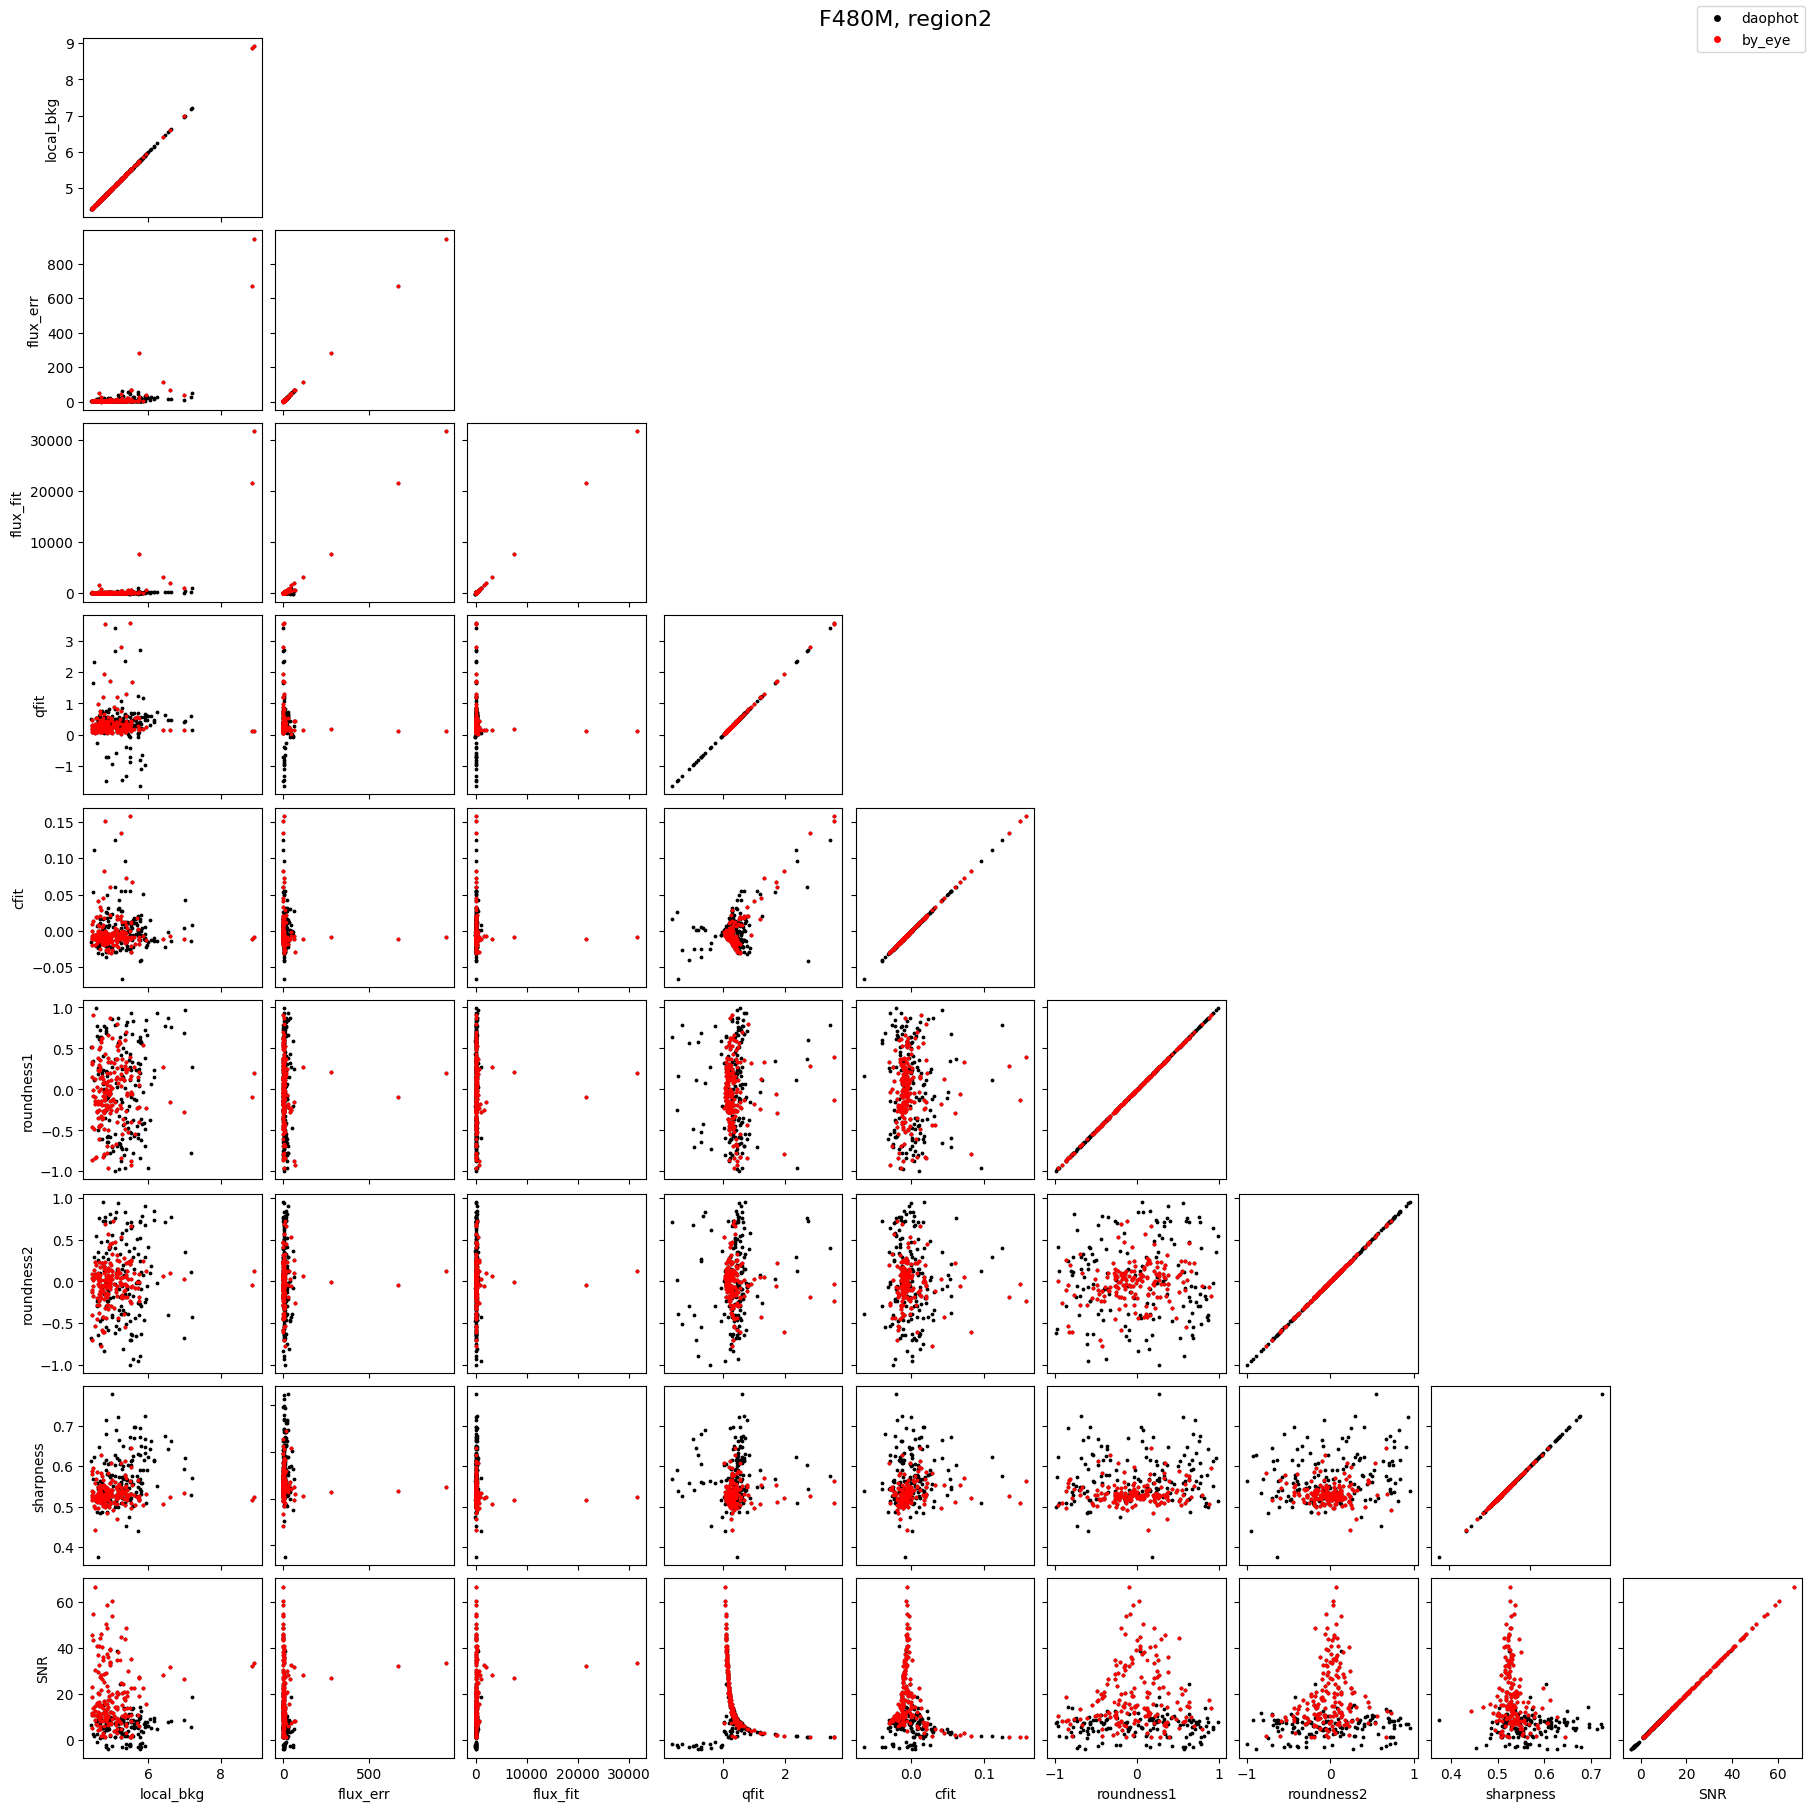

In [95]:
n = len(cols)  # updated, now 8
fig, axes = plt.subplots(n, n, figsize=(18, 18), constrained_layout=True)

for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):
        ax = axes[i, j]

        if j > i:
            ax.set_visible(False)
            continue

        ax.scatter(plot_cols[col2], plot_cols[col1], s=3, c="k")
        ax.scatter(plot_cols_matched[col2], plot_cols_matched[col1], s=3, c="red")

        if i == n - 1:
            ax.set_xlabel(col2)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(col1)
        else:
            ax.set_yticklabels([])


fig.suptitle("F480M, region2", fontsize=16)





legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='k', markersize=6, label='daophot'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markersize=6, label='by_eye'),
]

fig.legend(handles=legend_elements)
